In [52]:
import pynini
import numpy as np
from typing import NamedTuple
from dataclasses import dataclass

In [53]:
ascii_table = pynini.SymbolTable()
ascii_table.add_symbol("<eps>")

for i in range(1, 1_000):
    ascii_table.add_symbol(chr(i))

In [54]:
lexicon = [
    "foo",
    "fee",
    "ffoo"
    "bar",
    "boar",
    "fbar",
]

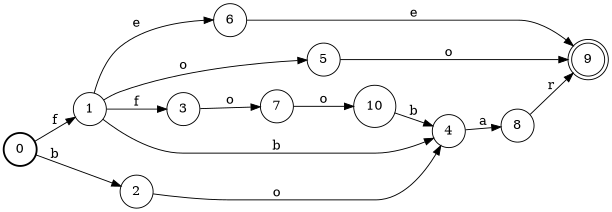

In [55]:
L = pynini.union(*lexicon)
L.set_input_symbols(ascii_table)
L.optimize()
L

In [56]:
L.fst_type()

'vector'

In [78]:
class WfsaCsr(NamedTuple):
    """
    Compressed Sparse Row representation of a WFSA with m states and n arcs.
    - `offsets`: n+1 array mapping state index to the first arc index
    - `next_states`: m array mapping arc index to target state index
    - `weights`: m array containing arc weights
    - `labels`: m array containing input labels for arcs
    """

    offsets: np.ndarray
    next_states: np.ndarray
    weights: np.ndarray
    labels: np.ndarray
    
    @classmethod
    def from_pynini(cls, wfsa: pynini.Fst) -> "WfsaCsr":
        """
        Compute a Compressed Sparse Row representation for the given FST.

        Arguments:
        - `fst`: the input FST to convert
        Returns:
        A `CSR` named tuple containing the CSR representation of the FST.
        """

        # beam search will expect a deterministic arc-sorted WFSA
        wfsa = pynini.determinize(wfsa)
        wfsa = pynini.arcsort(wfsa)

        n = wfsa.num_states()

        # first compute offsets by counting the number of arcs leaving each state
        offsets = np.zeros(n + 1, dtype=np.int32)
        for s in wfsa.states():
            offsets[s + 1] = wfsa.num_arcs(s)

        # then compute the prefix sum to get the starting index of arcs for each state
        np.cumsum(offsets, out=offsets)

        # the total number of arcs is the last value in offsets
        # (equivalent to the 'starting arc' of the final state, which has no outgoing arcs)
        total = int(offsets[-1])

        # arc arrays
        next_states = np.empty(total, dtype=np.int32)
        weights = np.empty(total, dtype=np.float32)
        labels = np.empty(total, dtype=np.int32)

        # populate the arc arrays by iterating over states and arcs
        for s in wfsa.states():
            i = offsets[s]
            for arc in wfsa.arcs(s):
                next_states[i] = arc.nextstate
                weights[i] = float(arc.weight)  # tropical -> float
                labels[i] = arc.ilabel
                i += 1

        return cls(
            offsets=offsets,
            next_states=next_states,
            weights=weights,
            labels=labels,
        )


@dataclass
class WfsaCsrBeam:
    left_state: int
    right_state: int
    path_weight: float
    labels: list[int]

In [79]:
WfsaCsr.from_pynini(L)

WfsaCsr(offsets=array([ 0,  2,  3,  7,  8,  9, 10, 11, 12, 12, 13, 14], dtype=int32), next_states=array([ 1,  2,  3,  3,  4,  5,  6,  7,  8,  9,  8,  8, 10,  3],
      dtype=int32), weights=array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32), labels=array([ 98, 102, 111,  98, 101, 102, 111,  97, 101, 111, 111, 114, 111,
        98], dtype=int32))

In [ ]:
def get_next_beams(
    beam: WfsaCsrBeam, left: WfsaCsr, right: WfsaCsr
) -> list[WfsaCsrBeam]:
    left_start_arc = left.offsets[beam.left_state]
    left_end_arc = left.offsets[beam.left_state + 1]

    right_start_arc = right.offsets[beam.right_state]
    right_end_arc = right.offsets[beam.right_state + 1]

    left_labels = left.labels[left_start_arc:left_end_arc]
    right_labels = right.labels[right_start_arc:right_end_arc]

    # since arcs are sorted, find matching labels
    # by checking for matches monotonically
    max_arcs = max(len(left_labels), len(right_labels))

    i = 0
    left_i = 0
    right_i = 0
    while (
        (i < max_arcs) and (left_i < len(left_labels)) and (right_i < len(right_labels))
    ):
        left_label = left_labels[left_i]
        right_label = right_labels[right_i]
        # TODO: check if we can add a beam or need to increment left/right_i


def intersect_beam(left: WfsaCsr, right: WfsaCsr, num_beam: int = 5) -> list[int]:
    """
    Compose left FstCsr with right, pruning the top `num_beams`
    paths.
    """

    # initialize w/ single beam starting at initial state
    initial_beam = WfsaCsrBeam(left_state=0, right_state=0, path_weight=0.0, labels=[])
    beams = [initial_beam]

    while beams:
        for beam in beams:
            ...